# DLA Cluster Variance Analysis Dashboard

Interactive analysis for determining optimal sample size using Standard Error analysis.


In [1]:
# Cell 1: Imports & Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.stats import linregress

# Set matplotlib style
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)


In [9]:
# Cell 2: Configuration & Parameters
MODEL = "OffLattice" # Options: "Lattice", "OffLattice", "Hybrid"
SIZE = "10M"  # Options: "1M", "10M"
DATA_DIR = Path(f"../results/analysis_clusters/{MODEL}/{SIZE}")  # Update this path to your .npz files directory
TARGET_SE = 0.005  # Target Standard Error for Fractal Dimension
# Check that the path exists and contains .npz files, and warn if not.
if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")
npz_files = list(DATA_DIR.glob("*.npz"))
if not npz_files:
    print(f"Warning: No .npz files found in DATA_DIR ({DATA_DIR}). Please check the path.")
else:
    print(f"Found {len(npz_files)} .npz files in {DATA_DIR}")


Found 100 .npz files in ../results/analysis_clusters/OffLattice/10M


In [3]:
# Cell 3: The Loading Kernel (Memory Optimized)
def process_batch(directory):
    """
    Memory-optimized batch processor for DLA cluster .npz files.
    
    Computes metrics on-the-fly and discards coordinate arrays immediately
    to avoid storing 1,000 arrays in memory.
    
    Returns:
        pandas.DataFrame with columns: N, R_max, R_g, D, anisotropy_ratio
    """
    directory = Path(directory)
    npz_files = sorted(directory.glob("*.npz"))
    
    if len(npz_files) == 0:
        raise ValueError(f"No .npz files found in {directory}")
    
    results = []
    
    # Try multiple possible keys for coordinates
    possible_keys = ['positions', 'coords', 'points']
    
    for npz_file in tqdm(npz_files, desc="Processing clusters"):
        try:
            # Use context manager to ensure file is properly closed
            with np.load(npz_file, allow_pickle=True) as data:
                # Find the coordinates array
                coords = None
                for key in possible_keys:
                    if key in data:
                        coords = data[key]
                        break
                
                if coords is None:
                    # Try to use the first array in the file
                    keys = list(data.keys())
                    if keys:
                        coords = data[keys[0]]
            
            if coords is None:
                print(f"Warning: Could not find coordinates in {npz_file.name}, skipping")
                continue
            
            # Cast to float32 immediately to save RAM (this creates a copy in memory)
            coords = np.asarray(coords, dtype=np.float32)
            
            # Handle different coordinate formats
            if coords.ndim == 2:
                if coords.shape[1] == 2:
                    # Shape (N, 2) - already correct
                    pass
                elif coords.shape[0] == 2:
                    # Shape (2, N) - transpose
                    coords = coords.T
                else:
                    print(f"Warning: Unexpected shape {coords.shape} in {npz_file.name}, skipping")
                    continue
            else:
                print(f"Warning: Unexpected dimensions {coords.ndim} in {npz_file.name}, skipping")
                continue
            
            # Filter out invalid values
            valid_mask = np.isfinite(coords).all(axis=1)
            coords = coords[valid_mask]
            
            if len(coords) < 10:
                print(f"Warning: Too few valid points in {npz_file.name}, skipping")
                continue
            
            # Compute metrics immediately (compute-on-load)
            # N: Mass (number of particles)
            N = len(coords)
            
            # For scaling dimension calculation, we need the positions in order
            # (assuming they're already in growth order, which is typical for DLA)
            x = coords[:, 0].astype(np.float64)
            y = coords[:, 1].astype(np.float64)
            
            # Calculate R_g(n) evolution for all n using cumulative sums
            # (Method from analyse_cluster.py - scaling relation)
            ns = np.arange(1, N + 1, dtype=np.float64)
            
            # Cumulative sums for Center of Mass (CM)
            cum_x = np.cumsum(x)
            cum_y = np.cumsum(y)
            
            # Cumulative sums for squared distances
            cum_x2 = np.cumsum(x**2)
            cum_y2 = np.cumsum(y**2)
            
            # CM at step n
            cm_x = cum_x / ns
            cm_y = cum_y / ns
            
            # Radius of Gyration squared at step n
            # Rg^2 = (1/N) * sum(r_i^2) - r_cm^2
            rg_sq = (cum_x2 + cum_y2) / ns - (cm_x**2 + cm_y**2)
            
            # Numerical stability: clamp negative epsilon to 0
            rg = np.sqrt(np.maximum(0.0, rg_sq))
            
            # Fitting range: 1% to 100% of N (same as analyse_cluster.py)
            start_idx = max(1, int(N * 0.01))
            
            fit_rg = rg[start_idx:]
            fit_ns = ns[start_idx:]
            
            # Remove any zero radii
            valid = fit_rg > 0
            fit_rg = fit_rg[valid]
            fit_ns = fit_ns[valid]
            
            # Calculate fractal dimension using scaling relation
            # R_g ~ N^(1/Df) => log(R_g) = (1/Df) * log(N) + C
            # Perform linear regression: slope = 1/Df => Df = 1/slope
            if len(fit_rg) >= 10:
                fit_log_n = np.log(fit_ns)
                fit_log_rg = np.log(fit_rg)
                
                slope, intercept, r_value, p_value, std_err = linregress(fit_log_n, fit_log_rg)
                D = 1.0 / slope if slope > 0 else np.nan
            else:
                D = np.nan
            
            # Also compute final R_g and R_max for anisotropy calculation
            # Use final center of mass for R_max calculation
            cm_final = np.array([cm_x[-1], cm_y[-1]])
            distances_final = np.linalg.norm(coords - cm_final, axis=1)
            R_max = float(np.max(distances_final))
            R_g = float(rg[-1])  # Final radius of gyration
            
            # Anisotropy Ratio: R_max / R_g
            anisotropy_ratio = R_max / R_g if R_g > 0 else np.nan
            
            # Store results
            results.append({
                'file': npz_file.name,
                'N': N,
                'R_max': R_max,
                'R_g': R_g,
                'D': D,
                'anisotropy_ratio': anisotropy_ratio
            })
            
            # Coordinates are automatically garbage collected here
            
        except Exception as e:
            print(f"Error processing {npz_file.name}: {e}")
            continue
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    return df


In [10]:
# Cell 4: Run Analysis
df = process_batch(DATA_DIR)

print("First few rows:")
print(df.head())
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
print(df.describe())


Processing clusters: 100%|██████████| 100/100 [05:05<00:00,  3.06s/it]


First few rows:
        file         N         R_max          R_g         D  anisotropy_ratio
0  10070.npz  10000001  10339.739672  6138.948911  1.699047          1.684285
1  10071.npz  10000001  10579.117869  6152.360921  1.698710          1.719522
2  10072.npz  10000001  10904.554371  6108.426116  1.715728          1.785166
3  10073.npz  10000001  11378.046410  6241.151417  1.678056          1.823068
4  10074.npz  10000001  10796.473447  6063.061591  1.718845          1.780697

Summary Statistics:
                N         R_max          R_g           D  anisotropy_ratio
count       100.0    100.000000   100.000000  100.000000        100.000000
mean   10000001.0  11045.322937  6183.636934    1.711695          1.785875
std           0.0    480.566106    82.614699    0.018313          0.065033
min    10000001.0  10020.244636  5973.539859    1.670386          1.648569
25%    10000001.0  10738.499760  6131.881914    1.700664          1.739616
50%    10000001.0  11020.552585  6181.177495 

In [11]:
# Cell 5: Statistical Power Analysis 
# Calculate Mean (μ) and Standard Deviation (σ) for D
D_mean = df['D'].mean()
D_std = df['D'].std()
current_n = len(df)

# Sample Size Calculator: M = (σ / TARGET_SE)^2
M_target_005 = (D_std / TARGET_SE) ** 2
M_target_01 = (D_std / 0.01) ** 2

# Print dynamic report
print("="*60)
print("STATISTICAL POWER ANALYSIS")
print("="*60)
print(f"Measured Mean (μ):              {D_mean:.6f}")
print(f"Measured Std Dev (σ):           {D_std:.6f}")
print(f"Current Sample Size:            {current_n}")
print(f"\nProjected Samples needed for SE=0.005:  {M_target_005:.0f}")
print(f"Projected Samples needed for SE=0.01:   {M_target_01:.0f}")
print("="*60)


STATISTICAL POWER ANALYSIS
Measured Mean (μ):              1.711695
Measured Std Dev (σ):           0.018313
Current Sample Size:            100

Projected Samples needed for SE=0.005:  13
Projected Samples needed for SE=0.01:   3


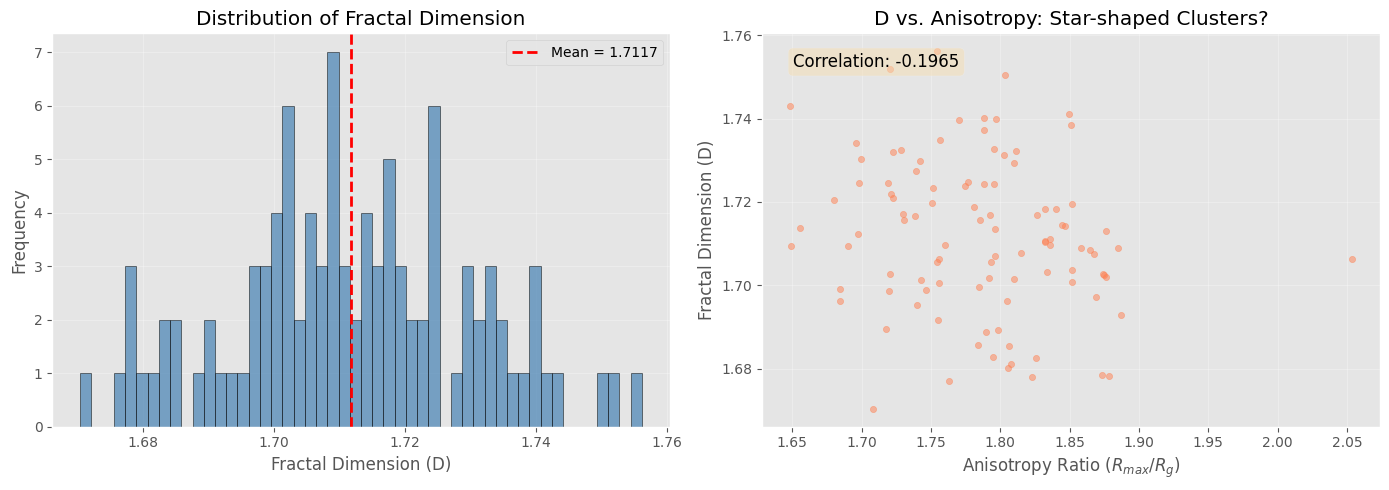


Correlation between D and Anisotropy Ratio: -0.1965
→ Weak correlation. Anisotropy does not strongly affect fractal dimension.


In [12]:
# Cell 6: Visualization Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of D (Fractal Dimension)
ax1.hist(df['D'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax1.axvline(D_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Mean = {D_mean:.4f}')
ax1.set_xlabel('Fractal Dimension (D)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Fractal Dimension')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter Plot: D vs. Anisotropy Ratio
ax2.scatter(df['anisotropy_ratio'], df['D'], alpha=0.5, s=20, color='coral')
ax2.set_xlabel('Anisotropy Ratio ($R_{max}/R_g$)')
ax2.set_ylabel('Fractal Dimension (D)')
ax2.set_title('D vs. Anisotropy: Star-shaped Clusters?')
ax2.grid(True, alpha=0.3)

# Calculate correlation
correlation = df[['anisotropy_ratio', 'D']].corr().iloc[0, 1]
ax2.text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
         transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print correlation interpretation
print(f"\nCorrelation between D and Anisotropy Ratio: {correlation:.4f}")
if abs(correlation) > 0.3:
    print("→ Significant correlation detected! Star-shaped clusters may have different dimensions.")
else:
    print("→ Weak correlation. Anisotropy does not strongly affect fractal dimension.")
